(525, 903, 3)


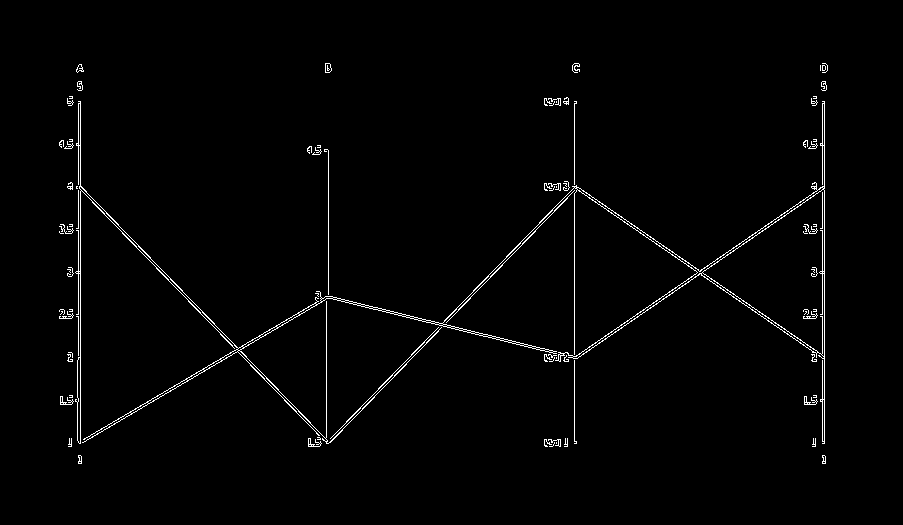

In [4]:
import cv2
from PIL import Image
img = cv2.imread("81.png")
print(img.shape)
# img = Image.fromarray(img)
# # img.show()

# display(img)
# gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# gray = cv2.equalizeHist(gray)
edges = cv2.Canny(img, 50, 150,L2gradient=True)
img = Image.fromarray(edges)
# img.show()
display(img)

In [7]:
import cv2
import os
import json
import numpy as np
from scipy.signal import find_peaks

def detect_vertical_axes(image_input, save_dir, output_json, apertureSize=5,
                         minLineLength=40, maxLineGap=1, method="hough"):
    os.makedirs(save_dir, exist_ok=True)
    results = []

    if os.path.isfile(image_input):
        image_files = [image_input]
    else:
        image_files = [
            os.path.join(image_input, f)
            for f in os.listdir(image_input)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

    for path in image_files:
        fname = os.path.basename(path)
        img = cv2.imread(path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray = cv2.equalizeHist(gray)

        def detect_by_hough():
            edges = cv2.Canny(gray, 50, 150, apertureSize=apertureSize)
            lines = cv2.HoughLinesP(edges, 1, np.pi / 4, 10,
                                    minLineLength=minLineLength, maxLineGap=maxLineGap)
            verticals = []
            if lines is not None:
                for line in lines:
                    x1, y1, x2, y2 = line[0]
                    if abs(x1 - x2) < 6:
                        verticals.append(((x1, y1), (x2, y2)))
            x_coords = [int((a[0] + b[0]) // 2) for a, b in verticals]
            return x_coords, verticals

        def detect_by_projection():
            _, binary = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
            vertical_sum = np.sum(binary, axis=0)
            smoothed = cv2.GaussianBlur(vertical_sum.astype(np.float32).reshape(1, -1), (25, 1), 0).flatten()
            peaks, _ = find_peaks(smoothed, distance=20, prominence=np.max(smoothed) * 0.3)
            return list(peaks)

        # Detection
        hough_coords, hough_lines = detect_by_hough() if method in ["hough", "combined"] else ([], [])
        proj_coords = detect_by_projection() if method in ["projection", "combined"] else []

        if method == "hough":
            final_coords = hough_coords
        elif method == "projection":
            final_coords = proj_coords
        elif method == "combined":
            combined = sorted(hough_coords + proj_coords)
            final_coords = []
            for x in combined:
                if len(final_coords) == 0 or abs(x - final_coords[-1]) > 6:
                    final_coords.append(x)

        # Draw vertical lines
        img_out = img.copy()
        for x in final_coords:
            cv2.line(img_out, (x, 0), (x, img.shape[0]), (0, 0, 255), 2)
        cv2.imwrite(os.path.join(save_dir, fname),
                    img_out)

        results.append({
            "image_name": fname,
            "x_coordinates": [int(x) for x in final_coords]
        })


    with open(output_json, 'w') as f:
        json.dump(results, f, indent=4)
    print(f"Vertical line data saved to {output_json}")
    return results


In [1]:
import cv2
import os
import json
import numpy as np
from scipy.signal import find_peaks

def detect_vertical_axes(image_input, save_dir, output_json, apertureSize=5,
                         minLineLength=20, maxLineGap=1, method="hough"):
    os.makedirs(save_dir, exist_ok=True)
    results = []

    if os.path.isfile(image_input):
        image_files = [image_input]
    else:
        image_files = [
            os.path.join(image_input, f)
            for f in os.listdir(image_input)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

    for path in image_files:
        fname = os.path.basename(path)
        img = cv2.imread(path)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray = cv2.equalizeHist(gray)

        def detect_by_hough():
            edges = cv2.Canny(gray, 50, 150, apertureSize=apertureSize)
            lines = cv2.HoughLinesP(edges, 1, np.pi / 4, 10,
                                    minLineLength=minLineLength, maxLineGap=maxLineGap)
            verticals = []
            if lines is not None:
                for line in lines:
                    x1, y1, x2, y2 = line[0]
                    if abs(x1 - x2) < 6:
                        verticals.append(((x1, y1), (x2, y2)))
            x_coords = [int((a[0] + b[0]) // 2) for a, b in verticals]
            return x_coords, verticals

        def detect_by_projection():
            _, binary = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
            vertical_sum = np.sum(binary, axis=0)
            smoothed = cv2.GaussianBlur(vertical_sum.astype(np.float32).reshape(1, -1), (25, 1), 0).flatten()
            peaks, _ = find_peaks(smoothed, distance=20, prominence=np.max(smoothed) * 0.3)
            return list(peaks)

        # Run detections
        hough_coords, _ = detect_by_hough() if method in ["hough", "combined"] else ([], [])
        proj_coords = detect_by_projection() if method in ["projection", "combined"] else []

        # Combine detections
        if method == "hough":
            final_coords = hough_coords
        elif method == "projection":
            final_coords = proj_coords
        elif method == "combined":
            combined = sorted(hough_coords + proj_coords)
            final_coords = []
            for x in combined:
                if len(final_coords) == 0 or abs(x - final_coords[-1]) > 6:
                    final_coords.append(x)

        # Filter bounding edges
        W = img.shape[1]
        final_coords = sorted(final_coords)
        filtered = [final_coords[0]] if final_coords else []
        for x in final_coords[1:]:
            if abs(x - filtered[-1]) > 20:
                filtered.append(x)
        if filtered and filtered[0] < 0.03 * W:
            filtered = filtered[1:]
        if filtered and filtered[-1] > 0.95 * W:
            filtered = filtered[:-1]

        # Draw and save
        img_out = img.copy()
        for x in filtered:
            cv2.line(img_out, (x, 0), (x, img.shape[0]), (0, 0, 255), 2)
        cv2.imwrite(os.path.join(save_dir, fname), img_out)

        results.append({
            "image_name": fname,
            "x_coordinates": [int(x) for x in filtered]
        })

    with open(output_json, 'w') as f:
        json.dump(results, f, indent=4)
    print(f"Vertical line data saved to {output_json}")
    return results


In [2]:
# # Only Hough
# detect_vertical_axes("images/", "out_hough/", "hough.json", method="hough")

# # Only projection
# detect_vertical_axes("images/", "out_proj/", "projection.json", method="projection")

# # Combined
detect_vertical_axes("images/", "out_comb2/", "combined.json", method="combined")


Vertical line data saved to combined.json


libpng warning: iCCP: profile 'icc': 0h: PCS illuminant is not D50


[{'image_name': 'r261.png', 'x_coordinates': [84, 218, 352, 486, 620, 755]},
 {'image_name': '29.png', 'x_coordinates': [98, 303, 507, 712]},
 {'image_name': '81.png', 'x_coordinates': [77, 326, 574, 822]},
 {'image_name': '28.png', 'x_coordinates': [41, 115, 244, 372, 449]},
 {'image_name': '171.png', 'x_coordinates': [61, 401, 716, 740, 1080]},
 {'image_name': '37.png', 'x_coordinates': [39, 134, 229, 324, 419]},
 {'image_name': '97.png', 'x_coordinates': [78, 348, 618]},
 {'image_name': '1.png', 'x_coordinates': []},
 {'image_name': '66.jpeg', 'x_coordinates': [60, 258, 456, 650]},
 {'image_name': '92.jpg', 'x_coordinates': [53, 323, 591, 860]},
 {'image_name': '142.png', 'x_coordinates': [162, 319, 466, 613, 760, 888]},
 {'image_name': 'paracoords.png',
  'x_coordinates': [167, 326, 485, 644, 803, 934, 962]},
 {'image_name': '105.png', 'x_coordinates': [83, 270, 456, 642, 829, 861]},
 {'image_name': '181.png', 'x_coordinates': [124, 147, 311, 497, 684]},
 {'image_name': '139.png', 